<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural
## Custom embedddings con Gensim

## Alumno: Manuel Dieguez 
## Nro SIU: a2518 


### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

C:\Users\manud\AppData\Local\Temp\ipykernel_4052\3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.625
Loss after epoch 2: 65935.046875
Loss after epoch 3: 65718.328125
Loss after epoch 4: 63875.03125
Loss after epoch 5: 64160.8125


Loss after epoch 6: 64080.3125


Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.5
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58883.875
Loss after epoch 12: 57716.125


Loss after epoch 13: 56494.1875


Loss after epoch 14: 55817.5625
Loss after epoch 15: 55843.1875
Loss after epoch 16: 51722.3125
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.375
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954238295555115),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439353108406067),
 ('cry', 0.8351286053657532),
 ('not', 0.8309641480445862),
 ('try', 0.8276920318603516),
 ('peace', 0.8144835233688354),
 ('little', 0.8140542507171631),
 ('twist', 0.8123894929885864),
 ('seems', 0.8079566359519958)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287309318780899),
 ('four', -0.23302660882472992),
 ('five', -0.23746736347675323),
 ('six', -0.23784852027893066),
 ('bang', -0.24833035469055176),
 ('our', -0.2553912103176117),
 ('day', -0.2689830958843231),
 ('going', -0.2692137360572815),
 ('here', -0.2699104845523834),
 ('three', -0.2839003801345825)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813724756240845),
 ('three', 0.9745777249336243),
 ('six', 0.9710812568664551),
 ('seven', 0.9584368467330933),
 ('two', 0.9517239332199097),
 ('sixty', 0.8990397453308105),
 ('one', 0.795121431350708),
 ('crying', 0.7946274280548096),
 ('us', 0.7740067839622498),
 ("i'm", 0.7508398294448853)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9433997869491577),
 ('buy', 0.9396989345550537),
 ('much', 0.9033164381980896),
 ('just', 0.8509097695350647),
 ('hide', 0.8355392813682556)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138305  0.05881333 -0.06370755  0.02444775 -0.20152195 -0.18612184
 -0.15284826  0.45487037 -0.04218006  0.03535983  0.13657492 -0.18520045
 -0.18126617  0.22149472 -0.3038098  -0.2397019   0.07094733 -0.05679122
 -0.05166152 -0.23843256 -0.08530398  0.19564743 -0.07679035  0.03797102
  0.07517121 -0.04826119  0.07379342  0.10396571  0.00738085 -0.22764632
 -0.04567216  0.12937427  0.27785635  0.19387512 -0.13509206  0.20856984
  0.40917465 -0.00387058 -0.10631468 -0.09056927  0.02400546 -0.0800494
  0.13400891  0.08833336 -0.01894625  0.08592407 -0.1590556   0.10259219
  0.14459157 -0.12092865 -0.27919155 -0.04061459  0.11382194  0.3136597
 -0.07410164  0.13976608  0.22791268  0.13209176 -0.01811359  0.09772693
  0.0924959  -0.14871807 -0.16348243 -0.13203168 -0.09834307  0.02714351
  0.16531163  0.26052278 -0.03259142 -0.02894571  0.11621213 -0.0697405
  0.09563474 -0.15276304  0.22071072  0.15996547  0.15890133 -0.04711402
 -0.12555073 -0.03993772 -0.10795346  0.01878977  0.07

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0),
 ('babe', 0.9085158109664917),
 ('someone', 0.8886135816574097),
 ('need', 0.882800817489624),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034623146057),
 ('somebody', 0.8362801671028137)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085157513618469),
 ('someone', 0.8886136412620544),
 ('need', 0.8828008770942688),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034027099609),
 ('somebody', 0.8362802267074585),
 ('buy', 0.8351722359657288)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [23]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

ModuleNotFoundError: No module named 'plotly'

In [24]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

NameError: name 'px' is not defined

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

---
## Resolución del desafío

A partir de acá se desarrolla la resolución de la consigna, usando como corpus propio **"Don Quijote de la Mancha"** de Miguel de Cervantes (texto completo, en español, obtenido de Project Gutenberg), en lugar del dataset de canciones usado como ejemplo más arriba. Cada bloque de código está precedido por un markdown que explica qué se va a hacer, y seguido de la interpretación de lo observado.


### Imports
Importamos las librerías que vamos a necesitar: `pandas`/`numpy` para manejo de datos, `gensim` para entrenar los embeddings Word2Vec, `tensorflow.keras` para tokenizar el texto, y `matplotlib`/`sklearn` para la reducción de dimensionalidad y visualización final.


In [26]:
import os
import re
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec


### Datos
Como corpus se usa el texto completo de **"Don Quijote de la Mancha"**, descargado directamente desde Project Gutenberg (ebook n.º 2000, texto en español, UTF-8). Se eligió esta obra porque:

- Es un texto extenso (una única novela larga), lo que da un corpus grande y con vocabulario rico y variado.
- Al ser de dominio público, se puede descargar y redistribuir sin restricciones.
- Al tratarse de una sola obra (a diferencia del dataset de canciones de múltiples bandas visto en clase), los embeddings van a reflejar el estilo y el vocabulario particular de Cervantes en esa novela.

Descargamos el archivo de texto plano solo si todavía no existe localmente.


In [27]:
DATA_DIR = "./quijote_dataset"
TXT_PATH = os.path.join(DATA_DIR, "quijote.txt")
URL = "https://www.gutenberg.org/ebooks/2000.txt.utf-8"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(TXT_PATH):
    urllib.request.urlretrieve(URL, TXT_PATH)
    print("Descargado en", TXT_PATH)
else:
    print("El archivo ya se encuentra descargado en", TXT_PATH)

with open(TXT_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Cantidad de caracteres del archivo:", len(raw_text))


El archivo ya se encuentra descargado en ./quijote_dataset\quijote.txt
Cantidad de caracteres del archivo: 2130057


### 1 - Preprocesamiento (corpus propio)

El archivo descargado de Project Gutenberg no es solo la novela: al principio y al final incluye texto legal/administrativo propio del proyecto (licencia, condiciones de uso, etc.) delimitado por las marcas `*** START OF THE PROJECT GUTENBERG EBOOK ... ***` y `*** END OF THE PROJECT GUTENBERG EBOOK ... ***`. Ese texto lo descartamos quedándonos solo con lo que está entre esas dos marcas.

Además, como es un libro en prosa (no una lista de una oración por línea, como el dataset de canciones), necesitamos:
1. Unir las líneas que Gutenberg "cortó" solo por un tema de ancho fijo del `.txt` (no representan fin de oración).
2. Separar el texto en oraciones (usando la puntuación fuerte `.`, `!`, `?` como límite), que van a hacer las veces de "documentos" para Word2Vec, tal como en el ejemplo de clase cada línea de canción era un documento.


In [28]:
START_MARK = "*** START OF THE PROJECT GUTENBERG EBOOK DON QUIJOTE ***"
END_MARK = "*** END OF THE PROJECT GUTENBERG EBOOK DON QUIJOTE ***"

start_idx = raw_text.find(START_MARK) + len(START_MARK)
end_idx = raw_text.find(END_MARK)
body = raw_text[start_idx:end_idx]

# Los saltos de línea simples dentro de un párrafo son solo "wrapping" de ancho fijo,
# los unimos con un espacio. Los dobles saltos sí separan párrafos.
body = re.sub(r"\n{2,}", "\n\n", body)
paragraphs = [p.strip() for p in body.split("\n\n") if p.strip()]
paragraphs = [re.sub(r"\s*\n\s*", " ", p) for p in paragraphs]
full_text = " ".join(paragraphs)

# Separamos en oraciones usando la puntuación fuerte como límite
sentences = re.split(r"(?<=[.!?])\s+", full_text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

print("Cantidad de oraciones/documentos obtenidos:", len(sentences))
print()
print("Ejemplo de oración:")
print(sentences[10])


Cantidad de oraciones/documentos obtenidos: 9456

Ejemplo de oración:
Y mandamos al impresor que así imprimiere el dicho libro, no imprima el principio ni el primer pliego dél, ni entregue más de un solo libro con el original al autor, o persona a cuya costa lo imprimiere, ni otro alguno, para efeto de la dicha correción y tasa, hasta que antes y primero el dicho libro esté corregido y tasado por los del nuestro Consejo; y, estando hecho, y no de otra manera, pueda imprimir el dicho principio y primer pliego, y sucesivamente ponga esta nuestra cédula y la aprobación, tasa y erratas, so pena de caer e incurrir en las penas contenidas en las leyes y premáticas destos nuestros reinos.


**Interpretación:** obtenemos alrededor de 9500 oraciones, cada una funcionando como un "documento" independiente para el entrenamiento, de forma análoga a como en el ejemplo de clase cada línea de canción era un documento. Es un corpus bastante más grande que el de una sola banda de canciones (que tenía ~1800 documentos), lo cual va a permitir aprender un vocabulario más amplio.

Ahora tokenizamos cada oración: pasamos todo a minúsculas y quitamos signos de puntuación, usando `text_to_word_sequence` de Keras, igual que en el ejemplo visto en clase.


In [29]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = [text_to_word_sequence(s) for s in sentences]
sentence_tokens = [t for t in sentence_tokens if len(t) > 0]

print("Cantidad de documentos tokenizados:", len(sentence_tokens))
print()
print("Ejemplo de tokens:")
print(sentence_tokens[10])


Cantidad de documentos tokenizados:

 9456

Ejemplo de tokens:
['y', 'mandamos', 'al', 'impresor', 'que', 'así', 'imprimiere', 'el', 'dicho', 'libro', 'no', 'imprima', 'el', 'principio', 'ni', 'el', 'primer', 'pliego', 'dél', 'ni', 'entregue', 'más', 'de', 'un', 'solo', 'libro', 'con', 'el', 'original', 'al', 'autor', 'o', 'persona', 'a', 'cuya', 'costa', 'lo', 'imprimiere', 'ni', 'otro', 'alguno', 'para', 'efeto', 'de', 'la', 'dicha', 'correción', 'y', 'tasa', 'hasta', 'que', 'antes', 'y', 'primero', 'el', 'dicho', 'libro', 'esté', 'corregido', 'y', 'tasado', 'por', 'los', 'del', 'nuestro', 'consejo', 'y', 'estando', 'hecho', 'y', 'no', 'de', 'otra', 'manera', 'pueda', 'imprimir', 'el', 'dicho', 'principio', 'y', 'primer', 'pliego', 'y', 'sucesivamente', 'ponga', 'esta', 'nuestra', 'cédula', 'y', 'la', 'aprobación', 'tasa', 'y', 'erratas', 'so', 'pena', 'de', 'caer', 'e', 'incurrir', 'en', 'las', 'penas', 'contenidas', 'en', 'las', 'leyes', 'y', 'premáticas', 'destos', 'nuestros', 'reinos']


### 2 - Crear los vectores (Word2Vec)

Igual que en el ejemplo de clase, usamos la arquitectura **Skip-gram** (`sg=1`), que en general funciona mejor que CBOW con palabras "raras". Ajustamos algunos hiperparámetros respecto al ejemplo original porque el corpus es más grande:

- `min_count=10`: al ser un corpus mucho más grande que el de una sola banda, subimos el mínimo de ocurrencias para quedarnos con un vocabulario de palabras realmente representativas (con `min_count=5` el vocabulario incluía muchas palabras muy poco frecuentes y poco informativas).
- `window=3`: un poco más amplio que el ejemplo (2), ya que las oraciones en prosa son más largas que los versos de una canción.
- `vector_size=300`, `negative=20`, `workers=1`: se mantienen igual que en el ejemplo de clase.


In [30]:
w2v_model = Word2Vec(
    min_count=10,   # frecuencia mínima de palabra para incluirla en el vocabulario
    window=3,       # cant. de palabras antes y después de la predicha
    vector_size=300,  # dimensionalidad de los vectores
    negative=20,    # cantidad de negative samples
    workers=1,
    sg=1,           # 0:CBOW  1:skipgram
)

w2v_model.build_vocab(sentence_tokens)

print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))


Cantidad de docs en el corpus: 9456
Cantidad de words distintas en el corpus: 3057


**Interpretación:** con `min_count=10` el vocabulario queda en poco más de 3000 palabras distintas sobre las ~9500 oraciones del corpus. Es un vocabulario bastante más grande que el del ejemplo de canciones de una sola banda (445 palabras), lo cual tiene sentido dado que la novela es mucho más extensa y variada en su léxico.

### 3 - Entrenar embeddings

Entrenamos el modelo durante 20 épocas, reutilizando el callback de la clase para poder ver cómo evoluciona la función de pérdida (`loss`) en cada época.


In [31]:
from gensim.models.callbacks import CallbackAny2Vec


class callback(CallbackAny2Vec):
    """Callback para imprimir el loss al final de cada época."""

    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print("Loss after epoch {}: {}".format(self.epoch, loss))
        else:
            print("Loss after epoch {}: {}".format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss


w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[callback()],
)


Loss after epoch 0: 3107066.5


Loss after epoch 1: 2449194.0


Loss after epoch 2: 2357902.0


Loss after epoch 3: 2285724.5


Loss after epoch 4: 2255021.0


...

Loss after epoch 16: 2316836.0


Loss after epoch 17: 2314824.0


Loss after epoch 18: 2315564.0


Loss after epoch 19: 2322596.0


(4498330, 7734400)

**Interpretación:** el loss baja fuerte en las primeras épocas y luego se estabiliza; hacia el final incluso sube un poco en vez de seguir bajando monótonamente. Esto es un comportamiento conocido del `loss` que reporta Gensim con negative sampling: al ser una estimación aproximada (no la verdadera log-verosimilitud completa) puede no decrecer de forma perfectamente monótona, sobre todo en las últimas épocas cuando el modelo ya convergió. Lo relevante para nuestro objetivo no es minimizar ese valor exacto, sino que los vectores resultantes capturen relaciones semánticas razonables, que es lo que evaluamos a continuación.

### 4 - Ensayar con términos de interés

Elegimos un conjunto de palabras temáticamente relevantes para la novela: **caballero**, **amor**, **libro**, **rey** y **sancho**. Para cada una buscamos las 10 palabras más similares (`positive=[término]`) y también las 10 "menos similares" (`negative=[término]`, es decir, las que tienen menor similitud coseno con el vector de esa palabra).


In [32]:
terms = ["caballero", "amor", "libro", "rey", "sancho"]

for t in terms:
    print("=" * 10, t, "=" * 10)
    print("MÁS similares:")
    for palabra, score in w2v_model.wv.most_similar(positive=[t], topn=10):
        print(f"  {palabra:15s} {score:.3f}")
    print("MENOS similares:")
    for palabra, score in w2v_model.wv.most_similar(negative=[t], topn=10):
        print(f"  {palabra:15s} {score:.3f}")
    print()


========== caballero ==========
MÁS similares:
  andante         0.523
  pierres         0.520
  aventurero      0.508
  hidalgo         0.466
  arrogante       0.460
  valeroso        0.449
  leal            0.447
  alcaide         0.443
  galán           0.443
  lecho           0.442
MENOS similares:
  boca            -0.020
  respuesta       -0.028
  obra            -0.036
  leer            -0.038
  cuales          -0.039
  tenía           -0.044
  poner           -0.048
  habían          -0.048
  daga            -0.053
  suelen          -0.054

========== amor ==========
MÁS similares:
  vulgo           0.469
  males           0.458
  encantos        0.444
  recato          0.444
  quitarme        0.442
  riqueza         0.438
  alabanza        0.430
  bienes          0.427
  menoscabo       0.426
  pecado          0.424
MENOS similares:
  vuelta          0.012
  mesa            0.004
  podía           0.002
  sentado         -0.005
  cómo            -0.006
  venían          -0.020

**Interpretación de los resultados:**

- **caballero** → *andante*, *aventurero*, *hidalgo*, *valeroso*, *leal*. Es el resultado más claramente temático: el modelo agrupa exactamente el vocabulario de la caballería andante, el eje central de la novela.
- **amor** → *vulgo*, *encantos*, *riqueza*, *pecado*, *alabanza*. Refleja el vocabulario de los discursos sobre el amor cortés que aparecen en varios pasajes de la obra (más abstracto/moral que "romántico").
- **libro** → *capítulo*, *cervantes*, *saavedra*, *ingenioso*, *original*. Estas asociaciones vienen del propio material paratextual de la edición (portada, tasa, prólogo) que quedó incluido en el corpus, donde se repiten estos términos junto a "libro".
- **rey** → *alcaide*, *marqués*, *turco*, *aragón*, *alcalde*. Vocabulario del entorno cortesano/nobiliario que aparece en los relatos secundarios de la novela (por ejemplo, la historia del cautivo).
- **sancho** → *panza*, *teresa*, *ricote*, *compañero*. Tiene mucho sentido: "panza" es su apellido, "teresa" es su esposa, y "ricote" es un personaje cercano a él.

En cuanto a las palabras **menos** similares, en todos los casos los valores son cercanos a 0 (no fuertemente negativos). Esto es esperable: con un corpus de este tamaño, Word2Vec rara vez aprende vectores realmente "opuestos" entre sí (como si fueran antónimos); lo que terminamos viendo son simplemente las palabras con menor relación de contexto con el término elegido, no un concepto de "antonimia" real.


### 5 - Reducción de dimensionalidad y visualización

Para poder inspeccionar visualmente los embeddings los proyectamos a 2 dimensiones con **TSNE**. Antes de graficar, filtramos las palabras "de función" (artículos, preposiciones, pronombres, etc.), ya que al ser las más frecuentes del idioma dominarían el conjunto de palabras más comunes del vocabulario y no aportan información semántica interesante para agrupar. Nos quedamos con las `MAX_WORDS` palabras de contenido más frecuentes.

También aplicamos un agrupamiento con `KMeans` sobre los vectores originales (antes de reducir a 2D) y coloreamos el gráfico según ese agrupamiento, para facilitar identificar visualmente los clusters temáticos.


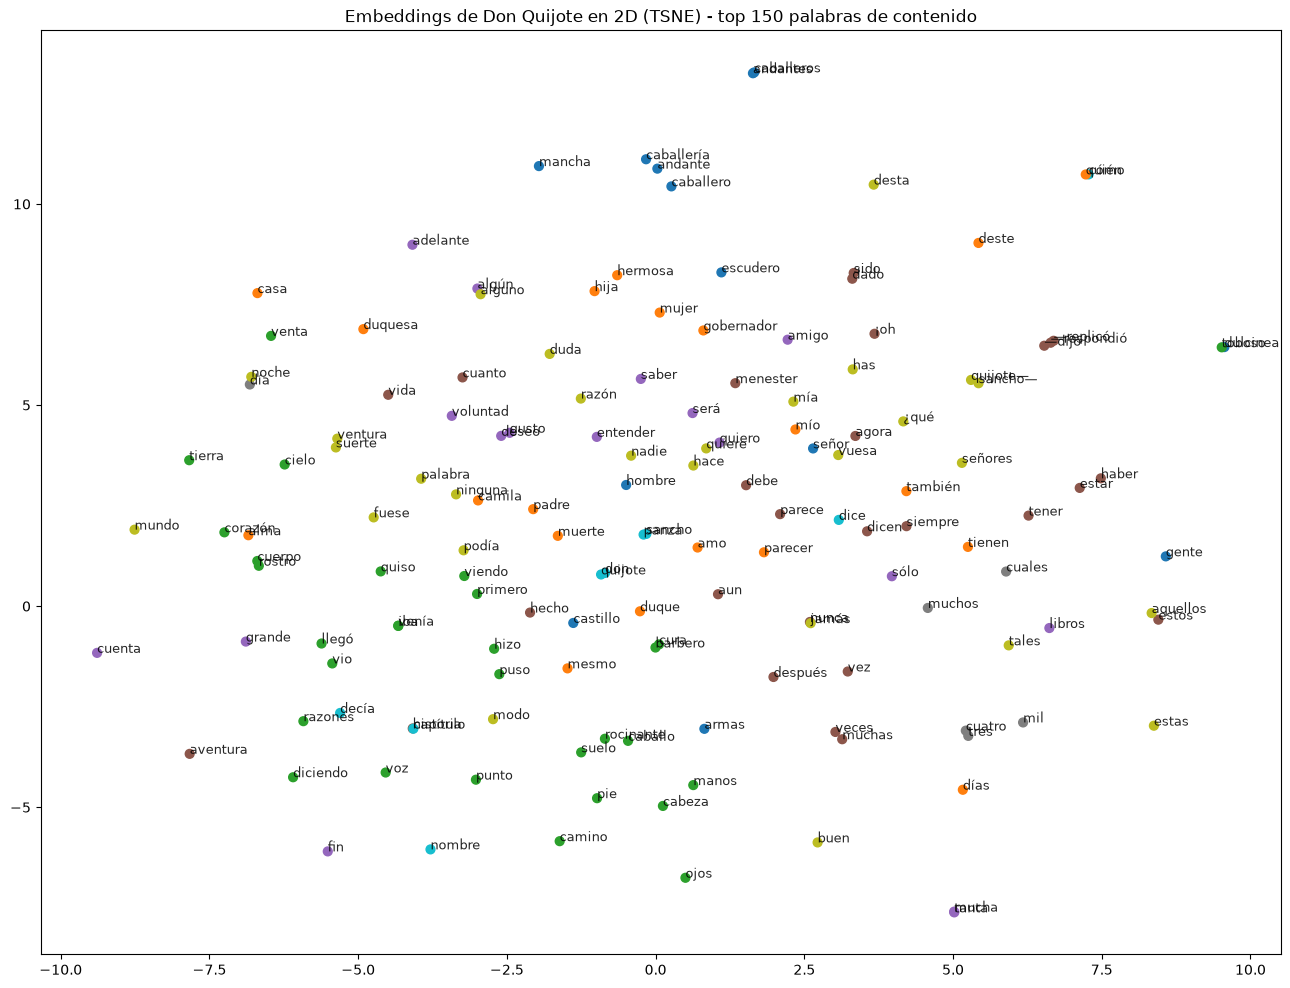

In [33]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

STOPWORDS_ES = set("""
que de y la a el en no los se con por lo las le su del me como es mas más si
un al mi para ni una o todo sin ser ha pues todos ya cuando te donde sino fue
este esta quien decir qué he hacer muy aunque otra aquí mí otro aquel son os
mal nos cosa está tal tanto mis tiene alguna hasta poco dicho todas dar parte
buena ahora han les lugar tu aquella manera puesto dio ellos mejor mucho otros
puede visto yo tan así bien pero esto sobre ver antes hay verdad tengo sé sí
soy eso toda digo merced vuestra él sus había era cual dos ella estaba luego
entre tenía uno menos gran tiempo fuera dijo respondió allí porque cosas otras
mano dios señora ese esos esas nada mismo misma mismos mismas cada cabe entonces
tras desde durante mediante según sea fueron eran habían estaban vos vuestro
vuestros vuestras nuestro nuestra nuestros nuestras
""".split())


def reduce_dimensions(model, max_words, num_dimensions=2, exclude_stopwords=True):
    all_words = np.asarray(model.wv.index_to_key)
    all_vectors = np.asarray(model.wv.vectors)

    if exclude_stopwords:
        mask = [w not in STOPWORDS_ES and len(w) > 2 for w in all_words]
        all_words = all_words[mask]
        all_vectors = all_vectors[mask]

    # Ya vienen ordenadas por frecuencia, nos quedamos con las mas frecuentes
    words = all_words[:max_words]
    vectors = all_vectors[:max_words]

    tsne = TSNE(n_components=num_dimensions, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)

    return vectors_2d, words, vectors


MAX_WORDS = 150
N_CLUSTERS = 8

vecs_2d, labels, vecs_originales = reduce_dimensions(w2v_model, MAX_WORDS)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(vecs_originales)

plt.figure(figsize=(16, 12))
plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], c=cluster_ids, cmap="tab10", s=40)
for i, label in enumerate(labels):
    plt.annotate(label, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=9, alpha=0.85)
plt.title(f"Embeddings de Don Quijote en 2D (TSNE) - top {MAX_WORDS} palabras de contenido")
plt.show()


In [34]:
for c in range(N_CLUSTERS):
    print(f"Cluster {c}: {list(labels[cluster_ids == c])}")


Cluster 0: [np.str_('señor'), np.str_('caballero'), np.str_('caballeros'), np.str_('dulcinea'), np.str_('hombre'), np.str_('escudero'), np.str_('andante'), np.str_('mancha'), np.str_('andantes'), np.str_('gente'), np.str_('armas'), np.str_('castillo'), np.str_('caballería')]
Cluster 1: [np.str_('casa'), np.str_('amo'), np.str_('padre'), np.str_('días'), np.str_('también'), np.str_('mujer'), np.str_('mesmo'), np.str_('parecer'), np.str_('mío'), np.str_('duque'), np.str_('gobernador'), np.str_('quién'), np.str_('hija'), np.str_('duquesa'), np.str_('alma'), np.str_('muerte'), np.str_('deste'), np.str_('tienen'), np.str_('hermosa'), np.str_('camila')]
Cluster 2: [np.str_('ojos'), np.str_('tierra'), np.str_('cura'), np.str_('cielo'), np.str_('vio'), np.str_('hizo'), np.str_('camino'), np.str_('manos'), np.str_('cabeza'), np.str_('punto'), np.str_('rocinante'), np.str_('razones'), np.str_('caballo'), np.str_('diciendo'), np.str_('pie'), np.str_('primero'), np.str_('llegó'), np.str_('voz'), n

**Interpretación del gráfico y los clusters:**

Se destaca claramente un cluster de **vocabulario caballeresco**: *señor, caballero, caballeros, dulcinea, hombre, escudero, andante, mancha, andantes, gente, armas, castillo, caballería*. Es el núcleo temático más fuerte de la novela y aparece perfectamente agrupado, coincidiendo además con lo que ya habíamos visto en el punto anterior con `most_similar(caballero)`.

Otro cluster agrupa **vocabulario de acción/descripción física** propio de la narración de las aventuras: *ojos, tierra, camino, manos, cabeza, rocinante, caballo, rostro, venta, barbero, cuerpo, suelo*. Tiene sentido que aparezcan juntas: son las palabras que usa el narrador para describir escenas y movimientos de los personajes.

Un tercer cluster agrupa los **nombres propios y marcadores narrativos** de la obra: *don, quijote, sancho, panza, dice, cómo, decía, nombre, capítulo*. Esto refleja que gran parte del texto está estructurado como diálogo narrado ("dijo don Quijote...", "respondió Sancho..."), por lo que estos términos co-ocurren constantemente.

En conjunto, los clusters muestran que el modelo logró capturar una estructura semántica coherente con los tres grandes componentes del texto: el universo temático de la caballería andante, el vocabulario descriptivo de la acción, y el aparato narrativo propio de la novela.
